In [54]:
# Importing required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [55]:
# Loading dataset

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df['species'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [56]:
df.shape

(150, 5)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [58]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


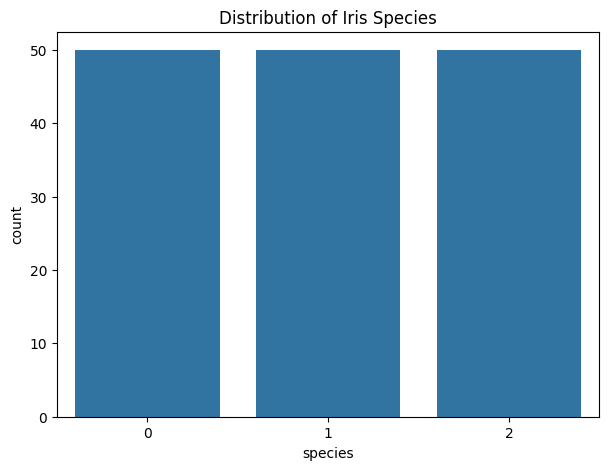

In [59]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='species',
    data=df
)

plt.title("Distribution of Iris Species")

plt.show()

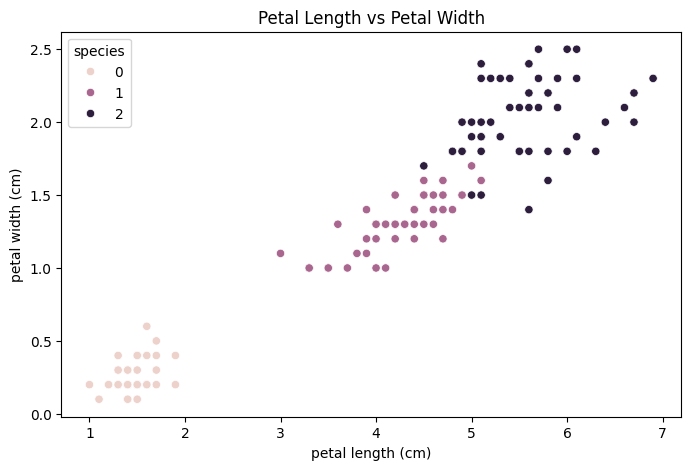

In [60]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['petal length (cm)'],
    y=df['petal width (cm)'],
    hue=df['species']
)

plt.title("Petal Length vs Petal Width")

plt.show()

In [61]:
X = df.drop('species', axis=1)

y = df['species']

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [63]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [64]:
model = KNeighborsClassifier(n_neighbors=5)

model.fit(
    X_train,
    y_train
)

KNeighborsClassifier()

In [65]:
y_pred = model.predict(X_test)

In [66]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Model Accuracy:", accuracy*100,"%")

Model Accuracy: 100.0 %


In [67]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



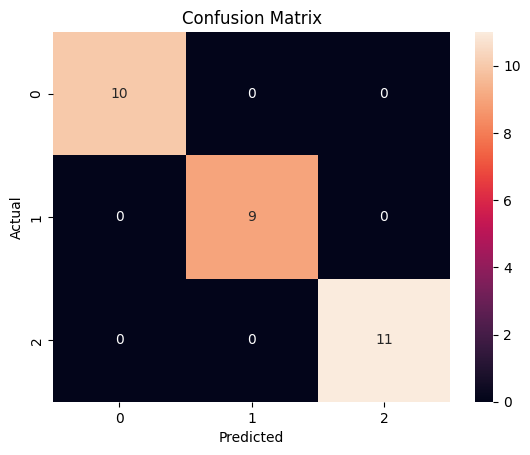

In [68]:
cm = confusion_matrix(
    y_test,
    y_pred
)


sns.heatmap(
    cm,
    annot=True
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()